In [2]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.preprocessing import LabelEncoder

In [3]:
aviationData = pd.read_csv('aviation_log.csv')
av_df = pd.DataFrame(aviationData, columns = ['Date','Time','Location','Operator','Flight #','Route','Type','Registration','cn/ln','Aboard','Fatalities','Ground','Summary'])
av_df.head()

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/ln,Aboard,Fatalities,Ground,Summary
0,09/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,NaN,2.0,1.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,07/12/1912,06:30,"AtlantiCity, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
2,08/06/1913,NaN,"Victoria, British Columbia, Canada",Private,-,NaN,Curtiss seaplane,NaN,NaN,1.0,1.0,0.0,The first fatal airplane accident in Canada oc...
3,09/09/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,14.0,0.0,The airship flew into a thunderstorm and encou...
4,10/17/1913,10:30,"Near Johannisthal, Germany",Military - German Navy,NaN,NaN,Zeppelin L-2 (airship),NaN,NaN,30.0,30.0,0.0,Hydrogen gas which was being vented was sucked...


In [15]:
av_df.rename(columns= {'Location': 'Incident_Location','Operator':'Airline_Operator','Type':'Aircraft_Type','Registration':'Registration_Number',
                   'Aboard':'People_Aboard','Fatalities':'Fatalities_Aboard','Ground':'Ground_Fatalities','Summary':'Event_Info'},inplace=True)

av_df.head()

,Date,Time,Incident_Location,Airline_Operator,Flight #,Route,Aircraft_Type,Registration_Number,cn/ln,People_Aboard,Fatalities_Aboard,Ground_Fatalities,Event_Info
0,09/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,NaN,2.0,1.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,07/12/1912,06:30,"AtlantiCity, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
2,08/06/1913,NaN,"Victoria, British Columbia, Canada",Private,-,NaN,Curtiss seaplane,NaN,NaN,1.0,1.0,0.0,The first fatal airplane accident in Canada oc...
3,09/09/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,14.0,0.0,The airship flew into a thunderstorm and encou...
4,10/17/1913,10:30,"Near Johannisthal, Germany",Military - German Navy,NaN,NaN,Zeppelin L-2 (airship),NaN,NaN,30.0,30.0,0.0,Hydrogen gas which was being vented was sucked...


In [16]:
print(f"Number of rows x number of columns: {av_df.shape}")
print(f"Total number of elements: {av_df.shape[0] * av_df.shape[1]} ")

Number of rows x number of columns: (5268, 13)
Total number of elements: 68484 


In [17]:
av_df.head(10)

,Date,Time,Incident_Location,Airline_Operator,Flight #,Route,Aircraft_Type,Registration_Number,cn/ln,People_Aboard,Fatalities_Aboard,Ground_Fatalities,Event_Info
0,09/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,NaN,2.0,1.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,07/12/1912,06:30,"AtlantiCity, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
2,08/06/1913,NaN,"Victoria, British Columbia, Canada",Private,-,NaN,Curtiss seaplane,NaN,NaN,1.0,1.0,0.0,The first fatal airplane accident in Canada oc...
3,09/09/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,14.0,0.0,The airship flew into a thunderstorm and encou...
4,10/17/1913,10:30,"Near Johannisthal, Germany",Military - German Navy,NaN,NaN,Zeppelin L-2 (airship),NaN,NaN,30.0,30.0,0.0,Hydrogen gas which was being vented was sucked...
5,03/05/1915,01:00,"Tienen, Belgium",Military - German Navy,NaN,NaN,Zeppelin L-8 (airship),NaN,NaN,41.0,21.0,0.0,Crashed into trees while attempting to land af...
6,09/03/1915,15:20,"Off Cuxhaven, Germany",Military - German Navy,NaN,NaN,Zeppelin L-10 (airship),NaN,NaN,19.0,19.0,0.0,"Exploded and burned near Neuwerk Island, when..."
7,07/28/1916,NaN,"Near Jambol, Bulgeria",Military - German Army,NaN,NaN,Schutte-Lanz S-L-10 (airship),NaN,NaN,20.0,20.0,0.0,"Crashed near the Black Sea, cause unknown."
8,09/24/1916,01:00,"Billericay, England",Military - German Navy,NaN,NaN,Zeppelin L-32 (airship),NaN,NaN,22.0,22.0,0.0,Shot down by British aircraft crashing in flames.
9,10/01/1916,23:45,"Potters Bar, England",Military - German Navy,NaN,NaN,Zeppelin L-31 (airship),NaN,NaN,19.0,19.0,0.0,Shot down in flames by the British 39th Home D...


In [18]:
av_df.describe(include = 'all')

,Date,Time,Incident_Location,Airline_Operator,Flight #,Route,Aircraft_Type,Registration_Number,cn/ln,People_Aboard,Fatalities_Aboard,Ground_Fatalities,Event_Info
count,5268,3049,5248,5250,1069,3561,5241,4933,0.0,5246.000000,5256.000000,5246.000000,4878
unique,4753,1005,4303,2476,724,3243,2446,4905,NaN,NaN,NaN,NaN,4673
top,06/18/1972,15:00,"Sao Paulo, Brazil",Aeroflot,-,Training,Douglas DC-3,49,NaN,NaN,NaN,NaN,Crashed during takeoff.
freq,4,32,15,179,67,81,334,3,NaN,NaN,NaN,NaN,15
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27.554518,20.068303,1.608845,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,43.076711,33.199952,53.987827,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,3.000000,0.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.000000,9.000000,0.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.000000,23.000000,0.000000,NaN


In [19]:
av_df.columns

Index(['Date', 'Time', 'Incident_Location', 'Airline_Operator', 'Flight #',
       'Route', 'Aircraft_Type', 'Registration_Number', 'cn/ln',
       'People_Aboard', 'Fatalities_Aboard', 'Ground_Fatalities',
       'Event_Info'],
      dtype='str')

In [20]:
av_df.info

<bound method DataFrame.info of             Date   Time                                  Incident_Location  \
0     09/17/1908  17:18                                Fort Myer, Virginia   
1     07/12/1912  06:30                            AtlantiCity, New Jersey   
2     08/06/1913    NaN                 Victoria, British Columbia, Canada   
3     09/09/1913  18:30                                 Over the North Sea   
4     10/17/1913  10:30                         Near Johannisthal, Germany   
...          ...    ...                                                ...   
5263  05/20/2009  06:30                             Near Madiun, Indonesia   
5264  05/26/2009    NaN                  Near Isiro, DemocratiRepubliCongo   
5265  06/01/2009  00:15  AtlantiOcean, 570 miles northeast of Natal, Br...   
5266  06/07/2009  08:30       Near Port Hope Simpson, Newfoundland, Canada   
5267  06/08/2009    NaN                  State of Arunachal Pradesh, India   

                     Airline_Op

In [21]:
av_df.dtypes

Date                       str
Time                       str
Incident_Location          str
Airline_Operator           str
Flight #                   str
Route                      str
Aircraft_Type              str
Registration_Number        str
cn/ln                  float64
People_Aboard          float64
Fatalities_Aboard      float64
Ground_Fatalities      float64
Event_Info                 str
dtype: object

In [22]:
av_df['Date'] = pd.to_datetime(av_df['Date'])

In [23]:
av_df['Year'] = av_df['Date'].dt.year.astype(int)
av_df['Month']= av_df['Date'].dt.month.astype(int)
av_df['Day']= av_df['Date'].dt.day.astype(int)
av_df.head()

,Date,Time,Incident_Location,Airline_Operator,Flight #,Route,Aircraft_Type,Registration_Number,cn/ln,People_Aboard,Fatalities_Aboard,Ground_Fatalities,Event_Info,Year,Month,Day
0,1908-09-17,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,NaN,2.0,1.0,0.0,"During a demonstration flight, a U.S. Army fly...",1908,9,17
1,1912-07-12,06:30,"AtlantiCity, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...,1912,7,12
2,1913-08-06,NaN,"Victoria, British Columbia, Canada",Private,-,NaN,Curtiss seaplane,NaN,NaN,1.0,1.0,0.0,The first fatal airplane accident in Canada oc...,1913,8,6
3,1913-09-09,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,14.0,0.0,The airship flew into a thunderstorm and encou...,1913,9,9
4,1913-10-17,10:30,"Near Johannisthal, Germany",Military - German Navy,NaN,NaN,Zeppelin L-2 (airship),NaN,NaN,30.0,30.0,0.0,Hydrogen gas which was being vented was sucked...,1913,10,17


In [24]:
av_df['Tota_Fatalities'] = av_df['Fatalities_Aboard']+av_df['Ground_Fatalities']
av_df.head()

,Date,Time,Incident_Location,Airline_Operator,Flight #,Route,Aircraft_Type,Registration_Number,cn/ln,People_Aboard,Fatalities_Aboard,Ground_Fatalities,Event_Info,Year,Month,Day,Tota_Fatalities
0,1908-09-17,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,NaN,2.0,1.0,0.0,"During a demonstration flight, a U.S. Army fly...",1908,9,17,1.0
1,1912-07-12,06:30,"AtlantiCity, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...,1912,7,12,5.0
2,1913-08-06,NaN,"Victoria, British Columbia, Canada",Private,-,NaN,Curtiss seaplane,NaN,NaN,1.0,1.0,0.0,The first fatal airplane accident in Canada oc...,1913,8,6,1.0
3,1913-09-09,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,14.0,0.0,The airship flew into a thunderstorm and encou...,1913,9,9,14.0
4,1913-10-17,10:30,"Near Johannisthal, Germany",Military - German Navy,NaN,NaN,Zeppelin L-2 (airship),NaN,NaN,30.0,30.0,0.0,Hydrogen gas which was being vented was sucked...,1913,10,17,30.0


In [25]:
av_df[(av_df.Tota_Fatalities == max(av_df.Tota_Fatalities))]

,Date,Time,Incident_Location,Airline_Operator,Flight #,Route,Aircraft_Type,Registration_Number,cn/ln,People_Aboard,Fatalities_Aboard,Ground_Fatalities,Event_Info,Year,Month,Day,Tota_Fatalities
4803,2001-09-11,08:47,"New York City, New York",American Airlines,11,Boston - Los Angeles,Boeing 767-223ER,N334AA,NaN,92.0,92.0,2750.0,The aircraft was hijacked shortly after it lef...,2001,9,11,2842.0


In [26]:
av_df[(av_df.Tota_Fatalities == max(av_df.Tota_Fatalities))]['Date']

4803   2001-09-11
Name: Date, dtype: datetime64[us]

In [27]:
av_df[(av_df.Tota_Fatalities == max(av_df.Tota_Fatalities))]['Event_Info']

4803    The aircraft was hijacked shortly after it lef...
Name: Event_Info, dtype: str

In [44]:
av_df.sort_values('Tota_Fatalities',ascending=False)[['Airline_Operator','Tota_Fatalities']].groupby('Airline_Operator').head(20)

,Airline_Operator,Tota_Fatalities
4803,American Airlines,2842.0
4804,United Air Lines,2815.0
2963,Pan American World Airways / KLM,583.0
3568,Japan Air Lines,520.0
4455,Saudi Arabian Airlines / Kazastan Airlines,349.0
...,...,...
678,Military - U.S. Army Air Corps,NaN
1186,Military - U.S. Air Force / U.S. Air Force,NaN
4705,Military - Ejército del Aire,NaN
4709,Universal Jet Aviation,NaN


In [48]:
av_df[(av_df.Airline_Operator=='South African Airways')].value_counts('Airline_Operator')/av_df.value_counts('Airline_Operator').sum() * 100

Airline_Operator
South African Airways    0.114286
Name: count, dtype: float64

In [50]:
# This gives the decimal percentage (e.g., 0.05 for 5%)
percentages = av_df['Airline_Operator'].value_counts(normalize=True) * 100

print(percentages['South African Airways'].round(2))

0.11


In [59]:
Fatalities_count = av_df[['Ground_Fatalities','Fatalities_Aboard']].sum()
Fatalities_count

Ground_Fatalities      8440.0
Fatalities_Aboard    105479.0
dtype: float64

Text(0.5, 1.0, 'Pie Chart for Fatalities')

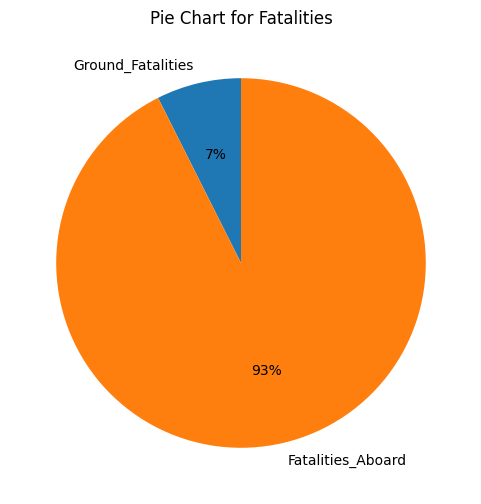

In [62]:
plt.pie(Fatalities_count.to_list(), labels = Fatalities_count.index, autopct = '%.0f%%', startangle=90)
fig = plt.gcf()
fig.set_size_inches(6, 6)
plt.title('Pie Chart for Fatalities')

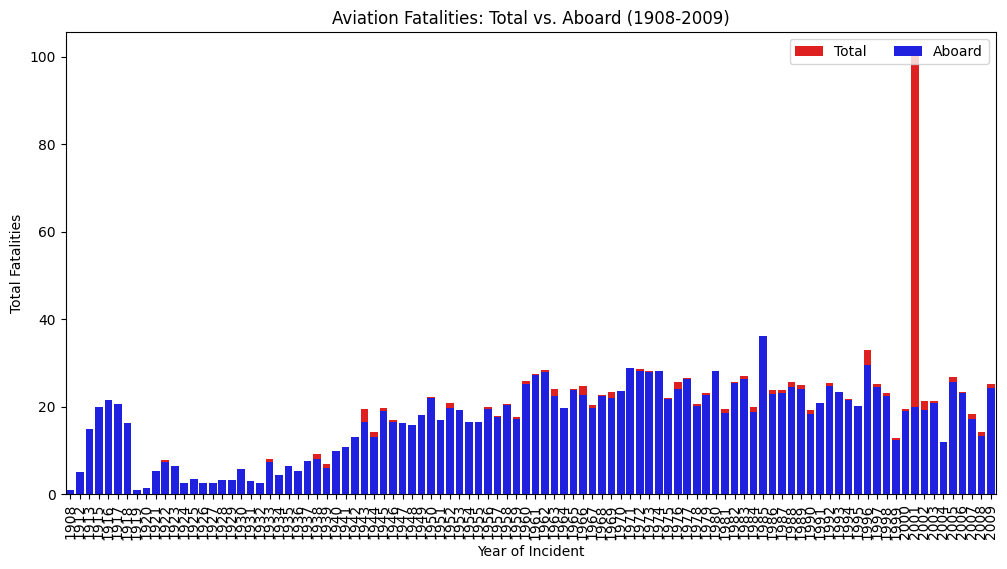

In [75]:
f, ax = plt.subplots(figsize=(12, 6))

# Red goes first (it's the larger 'background' bar)
sns.barplot(x='Year', y='Tota_Fatalities', data=av_df, color='r', label='Total', errorbar=None, ax=ax)

# Blue goes second (it's the 'overlay' bar)
sns.barplot(x='Year', y='Fatalities_Aboard', data=av_df, color='b', label='Aboard', errorbar=None, ax=ax)

plt.xticks(rotation=90)
ax.set_ylabel('Total Fatalities')
ax.set_xlabel('Year of Incident')
ax.set_title('Aviation Fatalities: Total vs. Aboard (1908-2009)')
ax.legend(ncol=2, loc="upper right", frameon=True)
plt.show()



In [76]:
av_df[(av_df.Fatalities_Aboard == max(av_df.Fatalities_Aboard))]['Aircraft_Type']

2963    Boeing B-747-121 / Boeing B-747-206B
Name: Aircraft_Type, dtype: str

In [79]:
av_df.drop(['Date','Time','Flight #','Route','Registration_Number','cn/ln','Event_Info'],axis=1,inplace=True)
av_df.head()

,Incident_Location,Airline_Operator,Aircraft_Type,People_Aboard,Fatalities_Aboard,Ground_Fatalities,Year,Month,Day,Tota_Fatalities
0,"Fort Myer, Virginia",Military - U.S. Army,Wright Flyer III,2.0,1.0,0.0,1908,9,17,1.0
1,"AtlantiCity, New Jersey",Military - U.S. Navy,Dirigible,5.0,5.0,0.0,1912,7,12,5.0
2,"Victoria, British Columbia, Canada",Private,Curtiss seaplane,1.0,1.0,0.0,1913,8,6,1.0
3,Over the North Sea,Military - German Navy,Zeppelin L-1 (airship),20.0,14.0,0.0,1913,9,9,14.0
4,"Near Johannisthal, Germany",Military - German Navy,Zeppelin L-2 (airship),30.0,30.0,0.0,1913,10,17,30.0


In [80]:
av_df.isnull().sum()

Incident_Location    20
Airline_Operator     18
Aircraft_Type        27
People_Aboard        22
Fatalities_Aboard    12
Ground_Fatalities    22
Year                  0
Month                 0
Day                   0
Tota_Fatalities      22
dtype: int64

In [87]:
av_df= av_df.dropna()

In [88]:
av_df.isnull().sum()

Incident_Location    0
Airline_Operator     0
Aircraft_Type        0
People_Aboard        0
Fatalities_Aboard    0
Ground_Fatalities    0
Year                 0
Month                0
Day                  0
Tota_Fatalities      0
dtype: int64

In [94]:
print(f"Airline Operator: {av_df['Airline_Operator'].unique}\n")
print(f"Aircraft Type: {av_df['Aircraft_Type'].unique}")

Airline Operator: <bound method Series.unique of 0                  Military - U.S. Army
1                  Military - U.S. Navy
2                               Private
3                Military - German Navy
4                Military - German Navy
                     ...               
5262         Military - Venezuelan Army
5263    Military - Indonesian Air Force
5265                         Air France
5266                         Strait Air
5267        Military - Indian Air Force
Name: Airline_Operator, Length: 5181, dtype: str>

Aircraft Type: <bound method Series.unique of 0                       Wright Flyer III
1                              Dirigible
2                       Curtiss seaplane
3                 Zeppelin L-1 (airship)
4                 Zeppelin L-2 (airship)
                      ...               
5262                               Mi-35
5263             Lockheed C-130 Hercules
5265                     Airbus A330-203
5266    Britten-Norman BN-2A-27 Islander
5267

In [99]:
av_df_Location = pd.get_dummies(av_df['Incident_Location'], dtype=int)
av_df_clean= pd.concat([av_df,av_df_Location],axis = 1)
av_df_clean.head(30)

,Incident_Location,Airline_Operator,Aircraft_Type,People_Aboard,Fatalities_Aboard,Ground_Fatalities,Year,Month,Day,Tota_Fatalities,...,"Zavnah, Mongolia","Zawoja, Poland","Zeleznogorsk, Russian","Zephyr Cove, Nevada","Zeya, Russia","Zheng Zou AB, China","Zifta, Egypt","Zurich, Switzerland","Zwingle, Iowa","near Orillia, Ontario, Canada"
0,"Fort Myer, Virginia",Military - U.S. Army,Wright Flyer III,2.0,1.0,0.0,1908,9,17,1.0,...,0,0,0,0,0,0,0,0,0,0
1,"AtlantiCity, New Jersey",Military - U.S. Navy,Dirigible,5.0,5.0,0.0,1912,7,12,5.0,...,0,0,0,0,0,0,0,0,0,0
2,"Victoria, British Columbia, Canada",Private,Curtiss seaplane,1.0,1.0,0.0,1913,8,6,1.0,...,0,0,0,0,0,0,0,0,0,0
3,Over the North Sea,Military - German Navy,Zeppelin L-1 (airship),20.0,14.0,0.0,1913,9,9,14.0,...,0,0,0,0,0,0,0,0,0,0
4,"Near Johannisthal, Germany",Military - German Navy,Zeppelin L-2 (airship),30.0,30.0,0.0,1913,10,17,30.0,...,0,0,0,0,0,0,0,0,0,0
5,"Tienen, Belgium",Military - German Navy,Zeppelin L-8 (airship),41.0,21.0,0.0,1915,3,5,21.0,...,0,0,0,0,0,0,0,0,0,0
6,"Off Cuxhaven, Germany",Military - German Navy,Zeppelin L-10 (airship),19.0,19.0,0.0,1915,9,3,19.0,...,0,0,0,0,0,0,0,0,0,0
7,"Near Jambol, Bulgeria",Military - German Army,Schutte-Lanz S-L-10 (airship),20.0,20.0,0.0,1916,7,28,20.0,...,0,0,0,0,0,0,0,0,0,0
8,"Billericay, England",Military - German Navy,Zeppelin L-32 (airship),22.0,22.0,0.0,1916,9,24,22.0,...,0,0,0,0,0,0,0,0,0,0
9,"Potters Bar, England",Military - German Navy,Zeppelin L-31 (airship),19.0,19.0,0.0,1916,10,1,19.0,...,0,0,0,0,0,0,0,0,0,0
